In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
df = pd.read_csv("AmesHousing.csv")

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.shape

(2930, 82)

In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64


In [8]:
df.dtypes.value_counts()

object     43
int64      28
float64    11
Name: count, dtype: int64

In [9]:
none_cols = [
'Pool QC','Misc Feature','Alley','Fence','Fireplace Qu',
'Mas Vnr Type','Garage Type','Garage Finish','Garage Qual','Garage Cond',
'Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2'
]

for col in none_cols:
    df[col] = df[col].fillna("None")

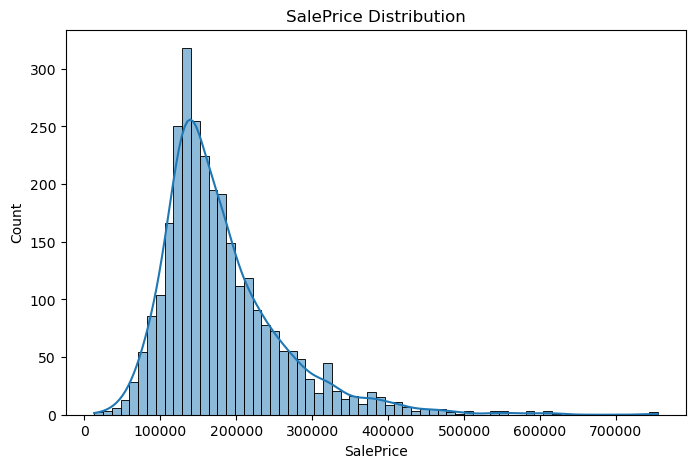

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

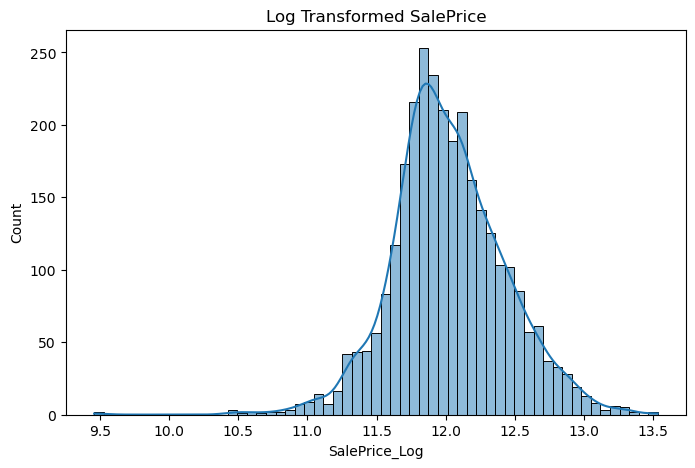

In [11]:
df['SalePrice_Log'] = np.log1p(df['SalePrice'])

plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice_Log'], kde=True)
plt.title("Log Transformed SalePrice")
plt.show()

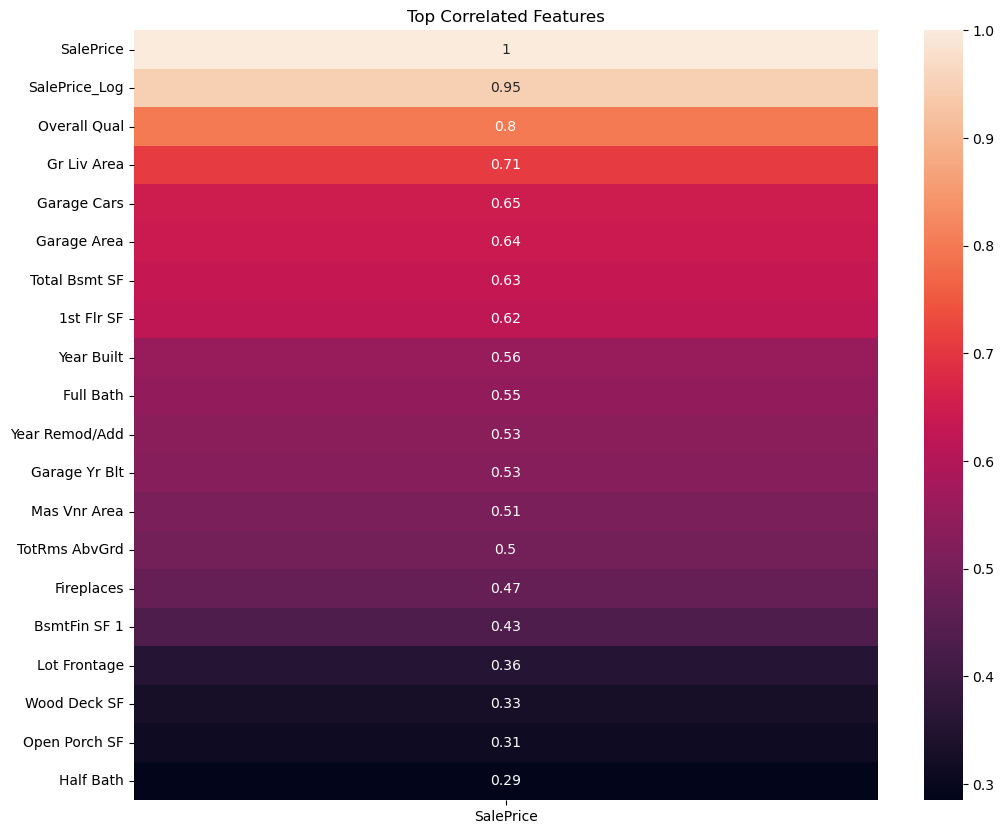

In [12]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr[['SalePrice']].sort_values(by='SalePrice', ascending=False).head(20), annot=True)
plt.title("Top Correlated Features")
plt.show()

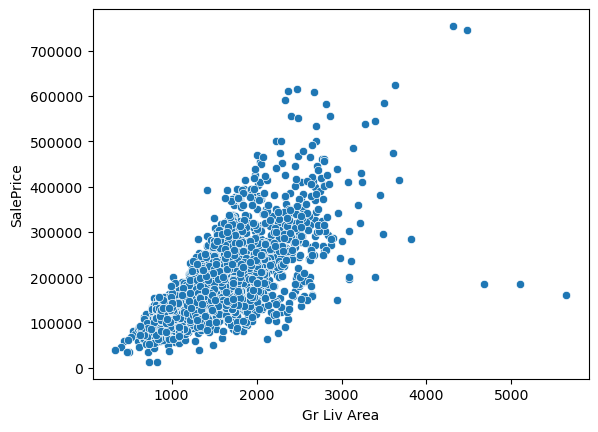

In [13]:
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)
plt.show()

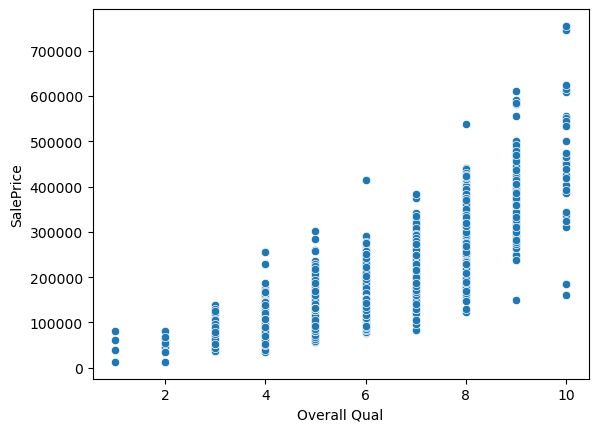

In [14]:
sns.scatterplot(x='Overall Qual', y='SalePrice', data=df)
plt.show()

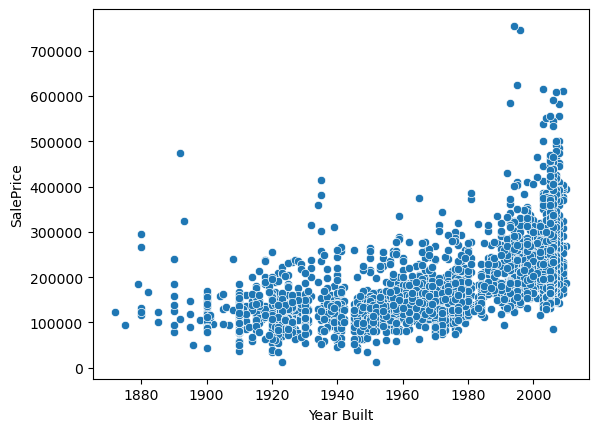

In [15]:
sns.scatterplot(x='Year Built', y='SalePrice', data=df)
plt.show()

In [16]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [17]:
df['TotalSF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']
df['HouseAge'] = df['Yr Sold'] - df['Year Built']
df['IsRemodeled'] = (df['Year Remod/Add'] != df['Year Built']).astype(int)
df['TotalBath'] = df['Full Bath'] + 0.5 * df['Half Bath']

In [18]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_13252\597453801.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_13252\597453801.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [19]:
df.isnull().sum()

Order            0
PID              0
MS SubClass      0
MS Zoning        0
Lot Frontage     0
                ..
SalePrice_Log    0
TotalSF          0
HouseAge         0
IsRemodeled      0
TotalBath        0
Length: 87, dtype: int64

In [20]:
df = pd.get_dummies(df, drop_first=True)

In [21]:
X = df.drop(['SalePrice','SalePrice_Log'], axis=1)
y = df['SalePrice_Log']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

print(X_train.shape, X_test.shape)

(2344, 281) (586, 281)


In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
lin_model = LinearRegression()
lin_model.fit(X_train,y_train)

y_pred_lin = lin_model.predict(X_test)

In [25]:
rmse_scores = []

k_values = [3,5,7,9,11,13,15]

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train,y_train)
    
    preds = knn.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test,preds))
    
    rmse_scores.append(rmse)

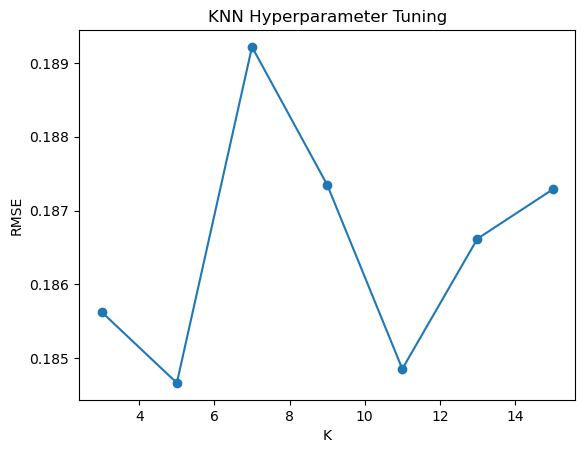

In [26]:
plt.plot(k_values, rmse_scores, marker='o')
plt.xlabel("K")
plt.ylabel("RMSE")
plt.title("KNN Hyperparameter Tuning")
plt.show()

In [27]:
knn_model = KNeighborsRegressor(n_neighbors=7)
knn_model.fit(X_train,y_train)

y_pred_knn = knn_model.predict(X_test)

In [28]:
depth_scores = []

for d in range(2,15):
    
    dt = DecisionTreeRegressor(max_depth=d)
    dt.fit(X_train,y_train)
    
    preds = dt.predict(X_test)
    score = r2_score(y_test,preds)
    
    depth_scores.append(score)

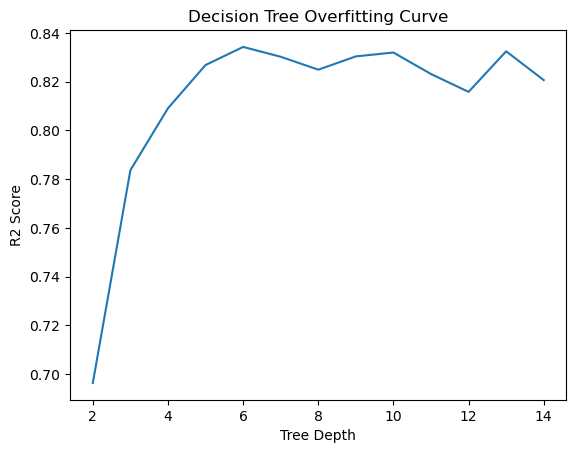

In [29]:
plt.plot(range(2,15), depth_scores)
plt.xlabel("Tree Depth")
plt.ylabel("R2 Score")
plt.title("Decision Tree Overfitting Curve")
plt.show()

In [30]:
dt_model = DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [31]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

# Feature Importance
importances = rf_model.feature_importances_

indices = np.argsort(importances)[-10:]

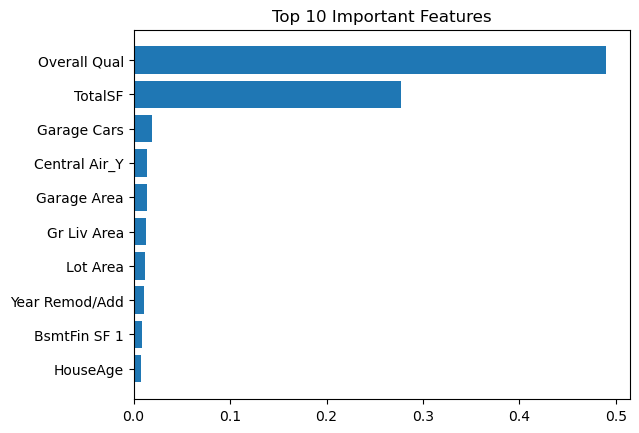

In [32]:
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), np.array(X.columns)[indices])
plt.title("Top 10 Important Features")
plt.show()

In [33]:
df['PriceClass'] = pd.qcut(df['SalePrice'],4,
labels=["Budget","Mid","UpperMid","Luxury"])

X_cls = df.drop(['SalePrice','SalePrice_Log','PriceClass'], axis=1)
y_cls = df['PriceClass']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls,y_cls,test_size=0.2,random_state=42
)

In [34]:
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train_c,y_train_c)

pred_log = log_model.predict(X_test_c)

print("Logistic Accuracy:", accuracy_score(y_test_c,pred_log))

Logistic Accuracy: 0.5017064846416383


c:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
nb = GaussianNB()
nb.fit(X_train_c,y_train_c)

pred_nb = nb.predict(X_test_c)

print("Naive Bayes Accuracy:", accuracy_score(y_test_c,pred_nb))

Naive Bayes Accuracy: 0.310580204778157


In [36]:
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [37]:
y_pred_xgb = xgb_model.predict(X_test)

In [38]:
# r2 = r2_score(y_test, y_pred_xgb)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
# mae = mean_absolute_error(y_test, y_pred_xgb)

# print("XGBoost Results")
# print("R2:", r2)
# print("RMSE:", rmse)
# print("MAE:", mae)

In [39]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
 
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
 
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
 
    Dense(64, activation='relu'),
    Dense(1, activation='linear')
])

c:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       144,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,513 (1.22 MB)

 Trainable params: 318,721 (1.22 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [41]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

In [42]:
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [43]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 121.8789 - mae: 10.6885 - val_loss: 29.6833 - val_mae: 4.9610 - learning_rate: 0.0010
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.2542 - mae: 1.7664 - val_loss: 7.4155 - val_mae: 2.6170 - learning_rate: 0.0010
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.9535 - mae: 1.0984 - val_loss: 1.7144 - val_mae: 1.2239 - learning_rate: 0.0010
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3778 - mae: 0.9214 - val_loss: 0.8015 - val_mae: 0.7694 - learning_rate: 0.0010
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.3405 - mae: 0.9225 - val_loss: 0.3579 - val_mae: 0.5187 - learning_rate: 0.0010
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.0317 - mae: 0.8158 - val_loss: 0.1960 - val_mae: 0.3222 - learning_rate: 0.0010
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.0774 - mae: 0.8190 - val_loss: 0.2403 - val_mae: 0.3850 - learning_rate: 0.0010
Ep

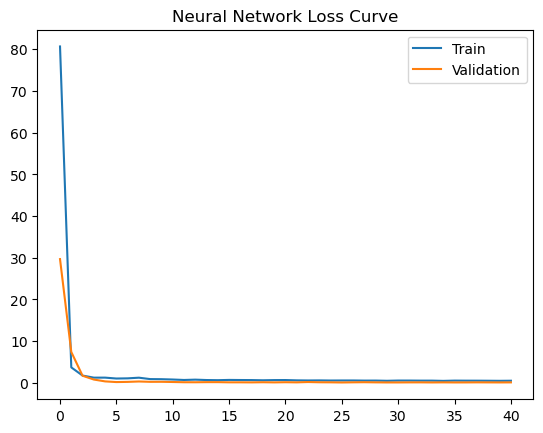

In [44]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Neural Network Loss Curve")
plt.legend(["Train","Validation"])
plt.show()

In [45]:
y_pred_nn = model.predict(X_test).flatten()

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [46]:
def evaluate(name, y_true, y_pred):
    
    r2 = r2_score(y_true,y_pred)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mae = mean_absolute_error(y_true,y_pred)
    
    print(name)
    print("R2:",r2)
    print("RMSE:",rmse)
    print("MAE:",mae)
    print()

In [47]:
evaluate("Linear Regression", y_test, y_pred_lin)
evaluate("KNN", y_test, y_pred_knn)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("Neural Network", y_test, y_pred_nn)
evaluate("XGBoost", y_test, y_pred_xgb)

Linear Regression
R2: -2287876214413.399
RMSE: 650633.6089111213
MAE: 27100.420030759447

KNN
R2: 0.8065045580820835
RMSE: 0.18921501703170418
MAE: 0.13793619294024448

Decision Tree
R2: 0.8388210143504042
RMSE: 0.17269288338900565
MAE: 0.12431177665223637

Random Forest
R2: 0.9201853920777509
RMSE: 0.1215238231357348
MAE: 0.0833019269371369

Neural Network
R2: 0.31710561098366985
RMSE: 0.3554651296792194
MAE: 0.24718339325504493

XGBoost
R2: 0.9426870957534254
RMSE: 0.10297847113225188
MAE: 0.07136598462679604



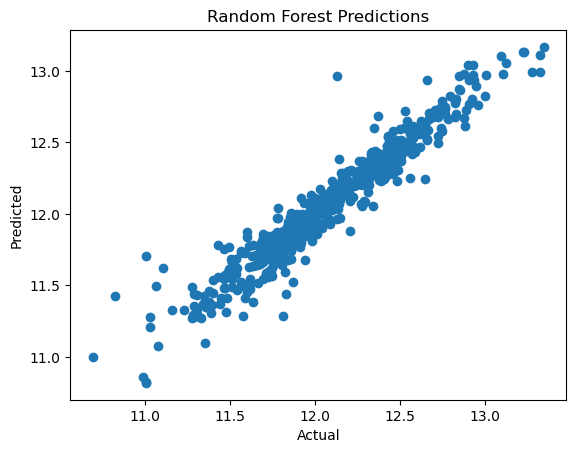

In [48]:
plt.scatter(y_test,y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Predictions")
plt.show()

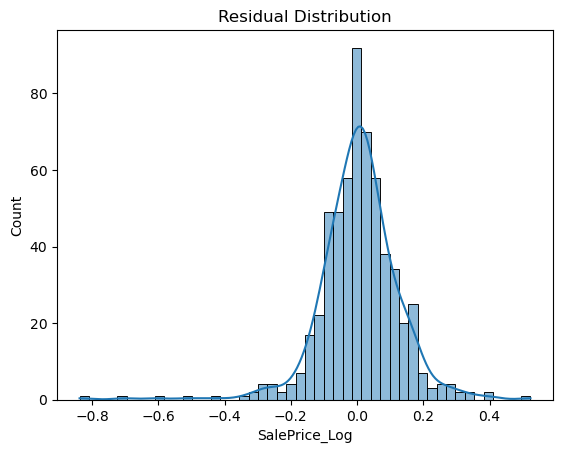

In [49]:
residuals = y_test - y_pred_rf

sns.histplot(residuals,kde=True)
plt.title("Residual Distribution")
plt.show()

In [50]:
models = [
    "Linear Regression",
    "KNN",
    "Decision Tree",
    "Random Forest",
    "Neural Network",
    "XGBoost"
]

In [51]:
r2_lin = r2_score(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mae_lin = mean_absolute_error(y_test, y_pred_lin)

r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))   
mae_rf = mean_absolute_error(y_test, y_pred_rf)

r2_nn = r2_score(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
mae_nn = mean_absolute_error(y_test, y_pred_nn)

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

In [52]:
r2_scores = [r2_lin, r2_knn, r2_dt, r2_rf, r2_nn, r2_xgb]
rmse_scores = [rmse_lin, rmse_knn, rmse_dt, rmse_rf, rmse_nn, rmse_xgb]
mae_scores = [mae_lin, mae_knn, mae_dt, mae_rf, mae_nn, mae_xgb]

x = np.arange(len(models))

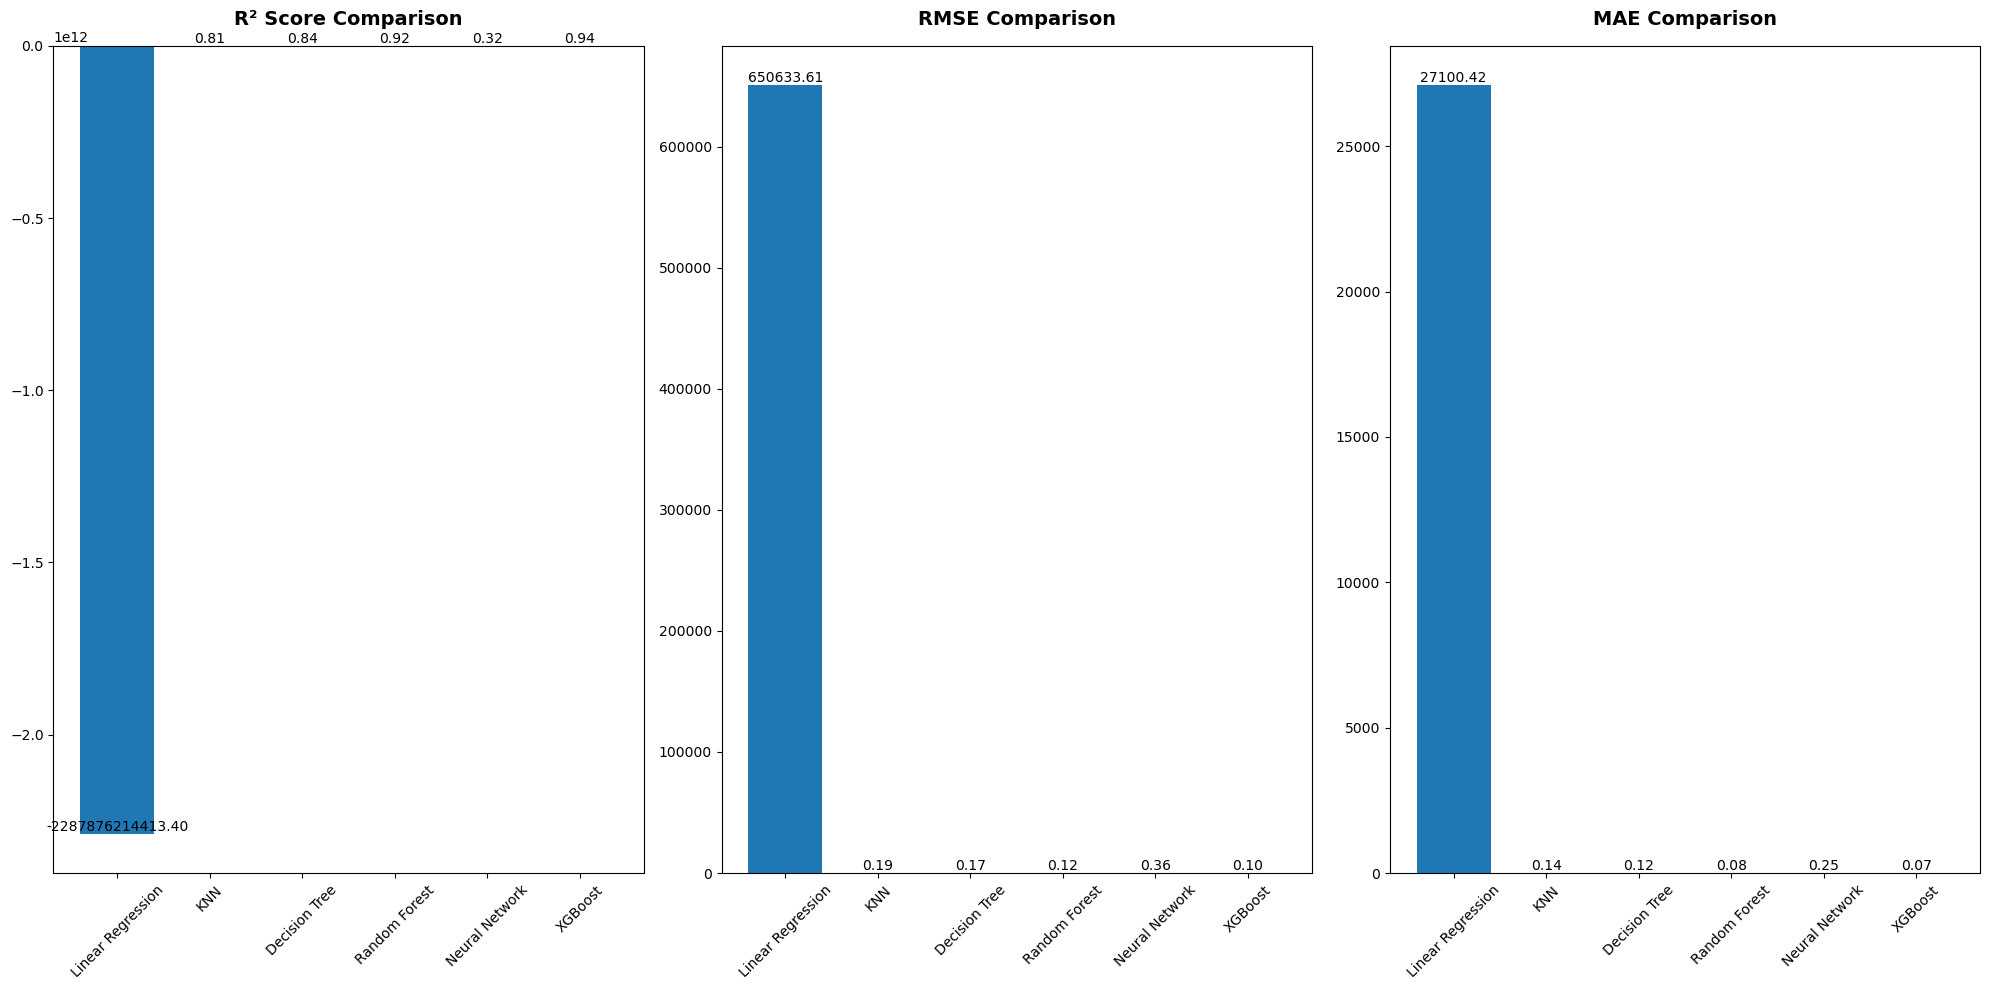

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# ---------------- R2 SCORE ----------------
bars1 = axes[0].bar(x, r2_scores)
axes[0].set_title("R² Score Comparison", pad=15, fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45)

for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval,
                 f"{yval:.2f}", ha='center', va='bottom')

# ---------------- RMSE ----------------
bars2 = axes[1].bar(x, rmse_scores)
axes[1].set_title("RMSE Comparison", pad=15, fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45)

for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval,
                 f"{yval:.2f}", ha='center', va='bottom')

# ---------------- MAE ----------------
bars3 = axes[2].bar(x, mae_scores)
axes[2].set_title("MAE Comparison", pad=15, fontsize=14, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45)

for bar in bars3:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, yval,
                 f"{yval:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [54]:
import pickle

with open("xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [55]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Scaler saved successfully!")

Scaler saved successfully!
